# Exploratory Data Analysis

The resulting data from `01_data_cleaning.ipynb` is explored here to identify patterns and trends which are shown through a variety of visualization. The visualizations are saved as PNGs under `reports/figures/eda/`.

In [1]:
from pathlib import Path
import sys, json, hashlib, subprocess, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, Code
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/us_migration').is_dir())
sys.path.insert(0, str(ROOT/'src'))
from us_migration.cleaning import api_frame, clean_acs, normalize_irs, canonical_irs_pairs, clean_acs_flows, clean_fema, clean_noaa
from us_migration.notebook_helpers import raw_snapshot, comparison_image, finish_chart, build_analysis_cohort, cohort_reasons, assert_clean_cohort, MEASURES, FEATURES, OUTCOMES
from us_migration.eda import profile, correlation_bundle, coverage
DATA = ROOT/'data/processed'
TABLES = ROOT/'reports/tables'
TABLES.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'axes.titlesize':15, 'axes.labelsize':11, 'xtick.labelsize':10, 'ytick.labelsize':10})
pd.set_option('display.max_columns', 14)


In [2]:
all_units=pd.read_parquet(DATA/'analysis_county_year.parquet')
assert_clean_cohort(all_units)
display(all_units.loc[all_units.geography_level.eq('state'),['county_name','year','inflow_individuals','outflow_individuals','net_individuals_per_1000']].tail(6))
# County comparisons use one geographic level; state observations remain in the analysis file.
clean=all_units.loc[all_units.geography_level.eq('county')].copy()
latest=int(clean.year.max())
cross=clean.loc[clean.year.eq(latest)].copy()
print(f'Validated cohort: {len(clean):,} county-years, {clean.year.min()}–{latest}; latest-year sample: {len(cross):,} counties')
display(clean[MEASURES].describe().T.round(2))
charts=[]
blue,teal,orange,red='#326c9d','#208b85','#d28b28','#b74e50'
money=FuncFormatter(lambda value,pos:f'${value/1000:,.0f}k')

,county_name,year,inflow_individuals,outflow_individuals,net_individuals_per_1000
46021,Alaska,2021,27210.0,31543.0,-5.887620
46022,Connecticut,2021,85831.0,85293.0,0.149224
46023,Alaska,2022,26567.0,31733.0,-7.030284
46024,Connecticut,2022,82190.0,88096.0,-1.635414
46025,Alaska,2023,25599.0,29748.0,-5.652812
46026,Connecticut,2023,76966.0,81733.0,-1.324775


Validated cohort: 45,997 county-years, 2009–2023; latest-year sample: 3,050 counties


,count,mean,std,min,25%,50%,75%,max
population,45997.0,102288.00,326178.81,241.00,11615.00,26401.00,68274.00,10105722.00
median_age,45997.0,40.85,5.20,21.40,37.80,40.80,43.80,68.40
median_household_income,45997.0,50676.52,15050.67,17109.00,40582.00,48125.00,57618.00,178707.00
median_home_value,45997.0,148809.04,97565.73,18700.00,90100.00,121900.00,171000.00,1494500.00
median_gross_rent,45997.0,735.59,234.27,99.00,585.00,683.00,822.00,2893.00
poverty_pct,45997.0,15.68,6.39,0.00,11.13,14.82,19.12,59.02
unemployment_pct,45997.0,6.78,3.29,0.00,4.46,6.36,8.67,32.42
vacancy_pct,45997.0,17.64,10.39,1.68,10.38,15.13,21.92,87.68
homeownership_pct,45997.0,72.34,8.00,18.97,68.34,73.52,77.75,97.39
bachelors_plus_pct,45997.0,20.87,8.77,3.23,14.96,18.79,23.92,80.21


## Visualization 1: Population spans several orders of magnitude

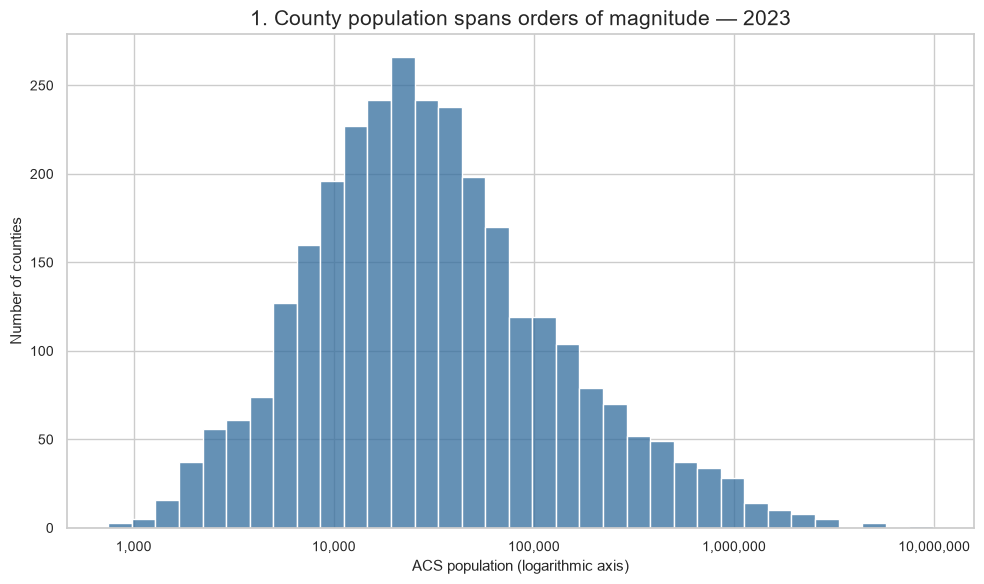

The median county population is 26,767, while the largest county has 9,848,406 residents in this sample. A logarithmic axis reveals smaller counties that a few very large counties would compress on a linear scale.

In [3]:
fig,ax=plt.subplots(figsize=(10,6))
sns.histplot(data=cross,x='population',bins=35,log_scale=True,color=blue,ax=ax)
ax.set(title=f'1. County population spans orders of magnitude — {latest}',xlabel='ACS population (logarithmic axis)',ylabel='Number of counties')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v:,.0f}'))
charts.append(finish_chart(fig,'01_population_distribution.png',
    f'The median county population is {cross.population.median():,.0f}, while the largest county has {cross.population.max():,.0f} residents in this sample.',
    'A logarithmic axis reveals smaller counties that a few very large counties would compress on a linear scale.'))

## Visualization 2: Home values have a long upper tail

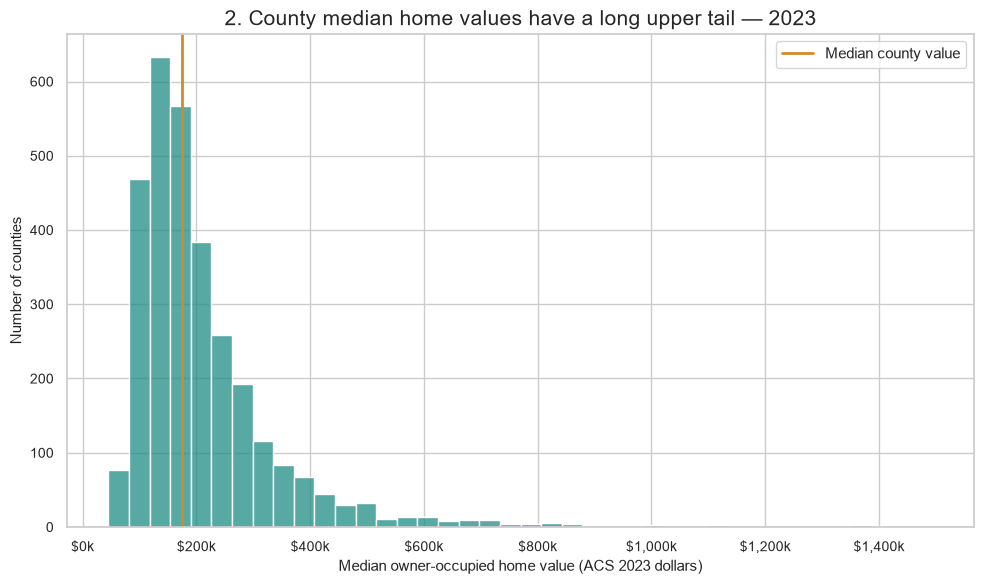

The median of county home-value estimates is $174,550, compared with a mean of $211,411. The upper tail motivates comparing ranks and inspecting extreme counties rather than automatically deleting high home values.

In [4]:
fig,ax=plt.subplots(figsize=(10,6))
sns.histplot(data=cross,x='median_home_value',bins=40,color=teal,ax=ax)
ax.axvline(cross.median_home_value.median(),color=orange,lw=2,label='Median county value')
ax.set(title=f'2. County median home values have a long upper tail — {latest}',xlabel=f'Median owner-occupied home value (ACS {latest} dollars)',ylabel='Number of counties')
ax.xaxis.set_major_formatter(money); ax.legend()
charts.append(finish_chart(fig,'02_home_value_distribution.png',
    f'The median of county home-value estimates is ${cross.median_home_value.median():,.0f}, compared with a mean of ${cross.median_home_value.mean():,.0f}.',
    'The upper tail motivates comparing ranks and inspecting extreme counties rather than automatically deleting high home values.'))

## Visualization 3: Migration varies within a fixed sample over time

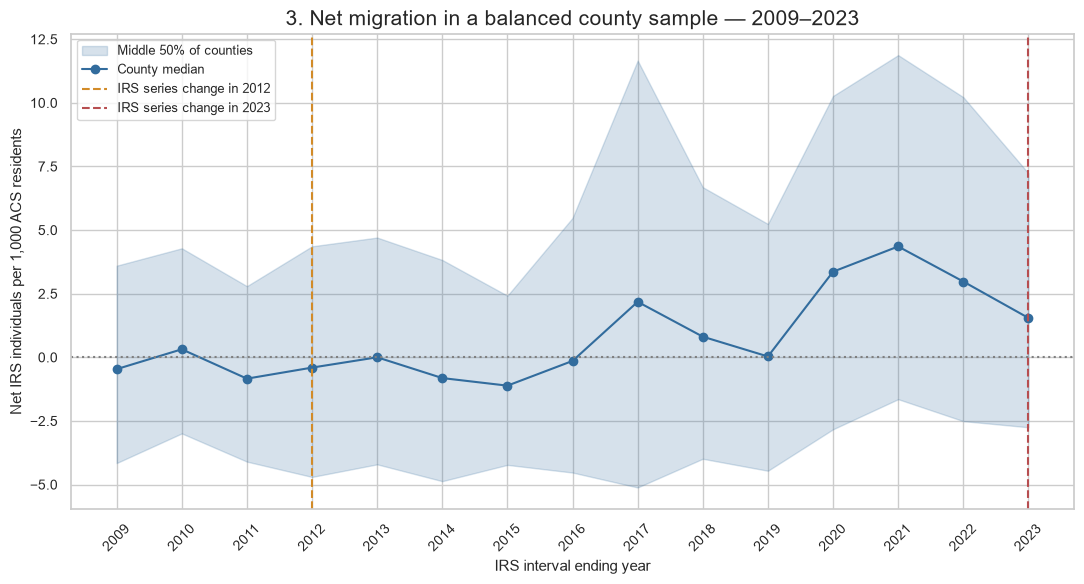

The line tracks median net migration for the same 3,008 counties observed in every plotted year, with the middle half shaded. This equal-county statistic is not a national population-weighted rate, and the marked IRS series changes limit comparisons across those breaks.

In [5]:
years=sorted(clean.year.unique())
balanced_ids=clean.groupby('county_fips').year.nunique().loc[lambda s:s.eq(len(years))].index
balanced=clean.loc[clean.county_fips.isin(balanced_ids)]
trend=balanced.groupby('year').net_individuals_per_1000.agg(median='median',q25=lambda s:s.quantile(.25),q75=lambda s:s.quantile(.75))
fig,ax=plt.subplots(figsize=(11,6))
ax.fill_between(trend.index,trend.q25,trend.q75,color=blue,alpha=.2,label='Middle 50% of counties')
ax.plot(trend.index,trend['median'],marker='o',color=blue,label='County median')
ax.axhline(0,color='gray',ls=':'); ax.axvline(2012,color=orange,ls='--',label='IRS series change in 2012'); ax.axvline(2023,color=red,ls='--',label='IRS series change in 2023')
ax.set(title=f'3. Net migration in a balanced county sample — {years[0]}–{latest}',xlabel='IRS interval ending year',ylabel='Net IRS individuals per 1,000 ACS residents',xticks=years)
ax.tick_params(axis='x',rotation=45); ax.legend(fontsize=9)
trend.to_csv(TABLES/'chart03_balanced_trend.csv')
charts.append(finish_chart(fig,'03_net_migration_over_time.png',
    f'The line tracks median net migration for the same {len(balanced_ids):,} counties observed in every plotted year, with the middle half shaded.',
    'This equal-county statistic is not a national population-weighted rate, and the marked IRS series changes limit comparisons across those breaks.'))

## Visualization 4: Inflow and outflow tend to move together

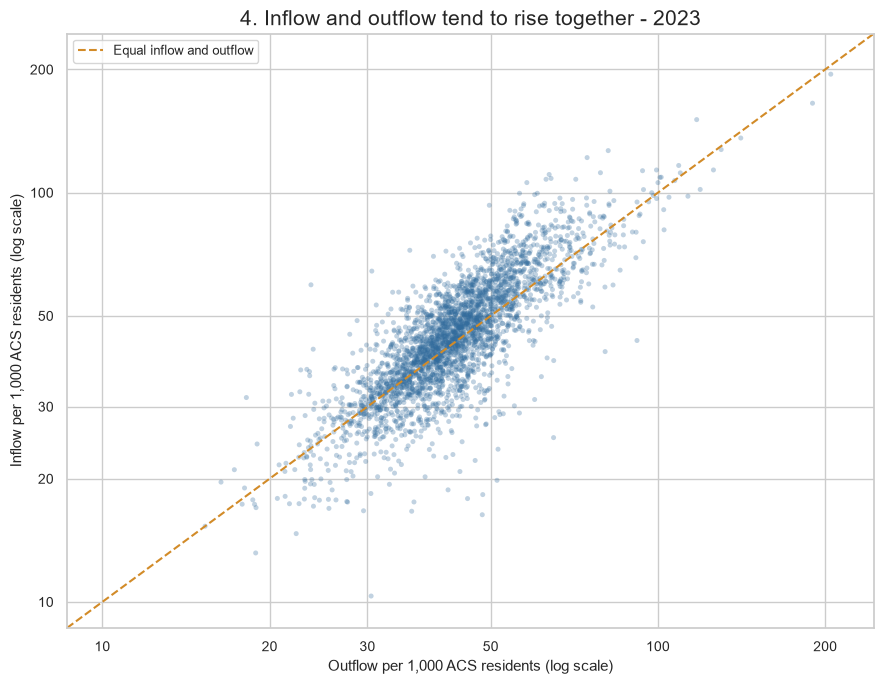

County inflow and outflow rates have a Spearman correlation of 0.80, illustrating substantial two-way movement. Counties above the diagonal gain IRS individuals on net, with matching logarithmic axes fitted to the observed range to spread out the points (symmetric logarithmic axes if zeros occur).

In [6]:
fig,ax=plt.subplots(figsize=(9,7))
ax.scatter(cross.outflow_individuals_per_1000,cross.inflow_individuals_per_1000,c=blue,alpha=.3,s=13,edgecolors='none')
rates=cross[['outflow_individuals_per_1000','inflow_individuals_per_1000']]
minimum=float(rates.min().min()); maximum=float(rates.max().max())
# Fit both axes to the observations with equal padding in transformed space.
scale='log' if minimum>0 else 'symlog'
if scale=='log':
    padding=(maximum/minimum)**0.06 if maximum>minimum else 1.1
    limits=(minimum/padding,maximum*padding)
    ax.set_xscale('log'); ax.set_yscale('log')
else:
    limits=(0,maximum*1.1)
    ax.set_xscale('symlog',linthresh=1); ax.set_yscale('symlog',linthresh=1)
ax.plot(limits,limits,ls='--',color=orange,label='Equal inflow and outflow')
ticks=[v for v in [0,1,2,5,10,20,30,50,100,200,300,500,1000] if limits[0]<=v<=limits[1]]
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v:,.0f}')); ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v:,.0f}'))
ax.xaxis.set_minor_formatter(plt.NullFormatter()); ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set(xlim=limits,ylim=limits,title=f'4. Inflow and outflow tend to rise together - {latest}',xlabel=f'Outflow per 1,000 ACS residents ({scale} scale)',ylabel=f'Inflow per 1,000 ACS residents ({scale} scale)')
ax.legend(fontsize=9)
rho=cross[['inflow_individuals_per_1000','outflow_individuals_per_1000']].corr(method='spearman').iloc[0,1]
charts.append(finish_chart(fig,'04_inflow_vs_outflow.png',
    f'County inflow and outflow rates have a Spearman correlation of {rho:.2f}, illustrating substantial two-way movement.',
    'Counties above the diagonal gain IRS individuals on net, with matching logarithmic axes fitted to the observed range to spread out the points (symmetric logarithmic axes if zeros occur).'))

## Visualization 5: Large gains and losses are geographically uneven

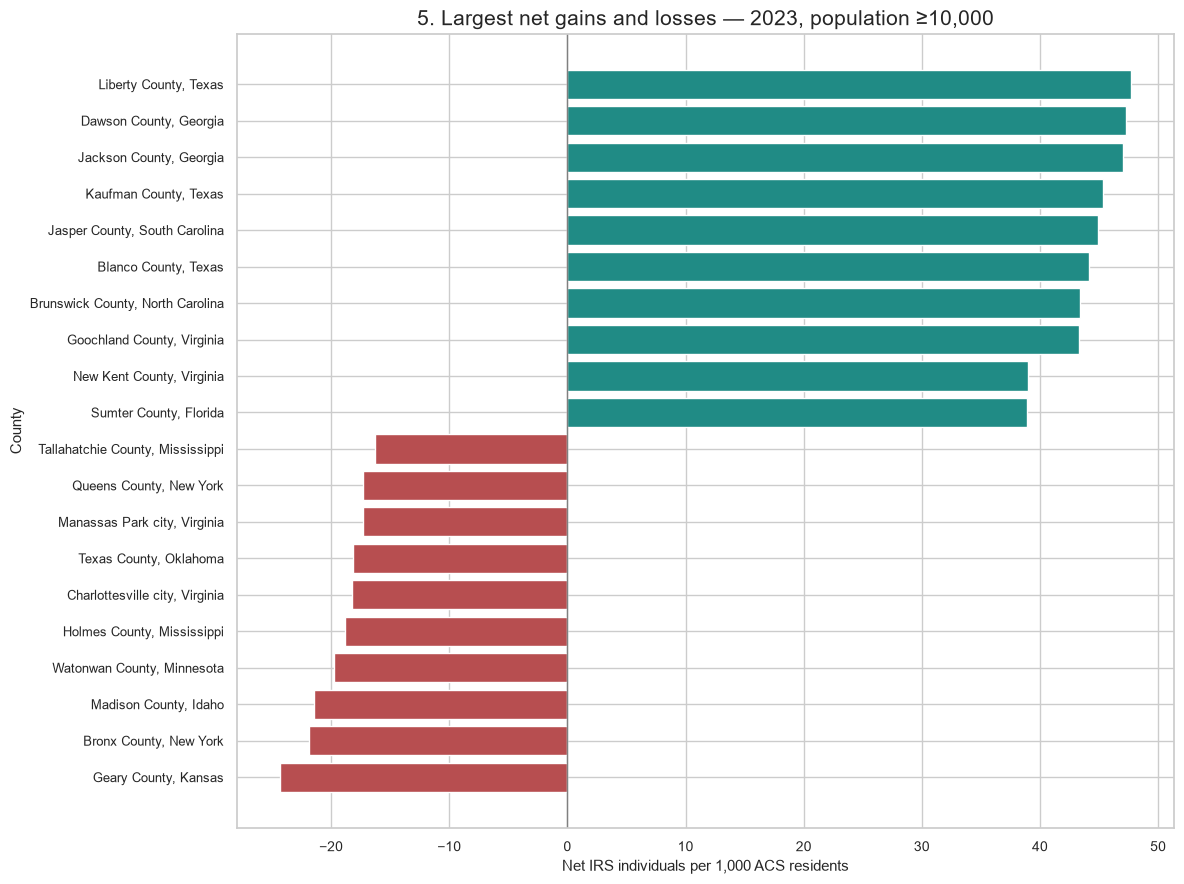

The chart compares the ten largest gains and ten largest losses among eligible counties with at least 10,000 ACS residents. The stated population threshold reduces tiny-denominator rankings, but rates still combine different IRS and ACS reference populations.

In [7]:
ranking=cross.loc[cross.population.ge(10000)].copy()
ranked=pd.concat([ranking.nsmallest(10,'net_individuals_per_1000'),ranking.nlargest(10,'net_individuals_per_1000')]).sort_values('net_individuals_per_1000')
fig,ax=plt.subplots(figsize=(12,9))
ax.barh(ranked.county_name,ranked.net_individuals_per_1000,color=np.where(ranked.net_individuals_per_1000.ge(0),teal,red))
ax.axvline(0,color='gray',lw=1)
ax.set(title=f'5. Largest net gains and losses — {latest}, population ≥10,000',xlabel='Net IRS individuals per 1,000 ACS residents',ylabel='County')
ax.tick_params(axis='y',labelsize=9)
ranked[['county_name','population','net_individuals_per_1000']].to_csv(TABLES/'chart05_county_rankings.csv',index=False)
charts.append(finish_chart(fig,'05_county_gains_and_losses.png',
    'The chart compares the ten largest gains and ten largest losses among eligible counties with at least 10,000 ACS residents.',
    'The stated population threshold reduces tiny-denominator rankings, but rates still combine different IRS and ACS reference populations.'))

## Visualization 6: Homeownership is associated with migration balance

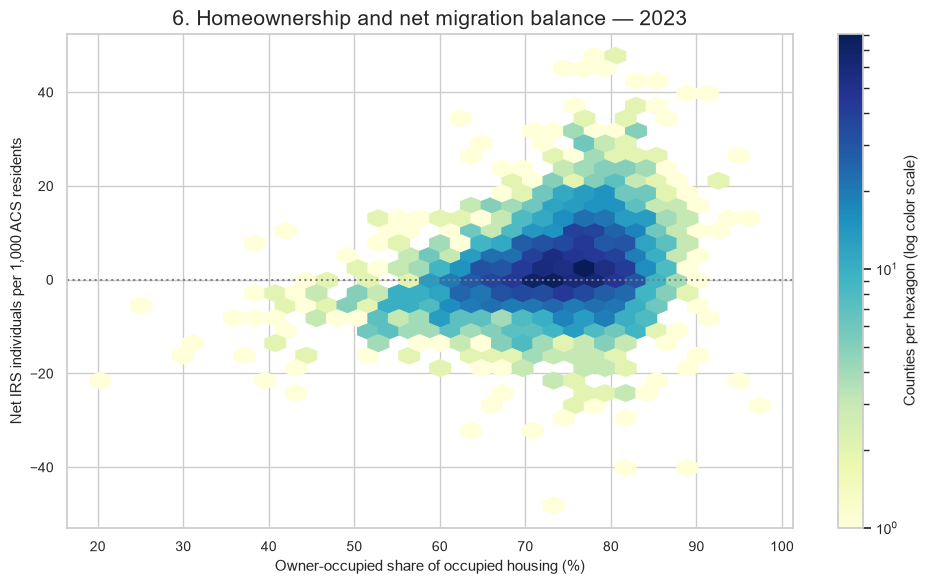

The Spearman association between homeownership and net migration is 0.29 in the county sample with training-imputed predictors. Hexagon density shows variation around this association and does not establish that homeownership causes migration.

In [8]:
fig,ax=plt.subplots(figsize=(10,6))
hexes=ax.hexbin(cross.homeownership_pct,cross.net_individuals_per_1000,gridsize=32,mincnt=1,bins='log',cmap='YlGnBu')
fig.colorbar(hexes,ax=ax,label='Counties per hexagon (log color scale)')
ax.axhline(0,color='gray',ls=':')
ax.set(title=f'6. Homeownership and net migration balance — {latest}',xlabel='Owner-occupied share of occupied housing (%)',ylabel='Net IRS individuals per 1,000 ACS residents')
rho=cross[['homeownership_pct','net_individuals_per_1000']].corr(method='spearman').iloc[0,1]
charts.append(finish_chart(fig,'06_homeownership_and_migration.png',
    f'The Spearman association between homeownership and net migration is {rho:.2f} in the county sample with training-imputed predictors.',
    'Hexagon density shows variation around this association and does not establish that homeownership causes migration.'))

## Visualization 7: Education groups have overlapping distributions

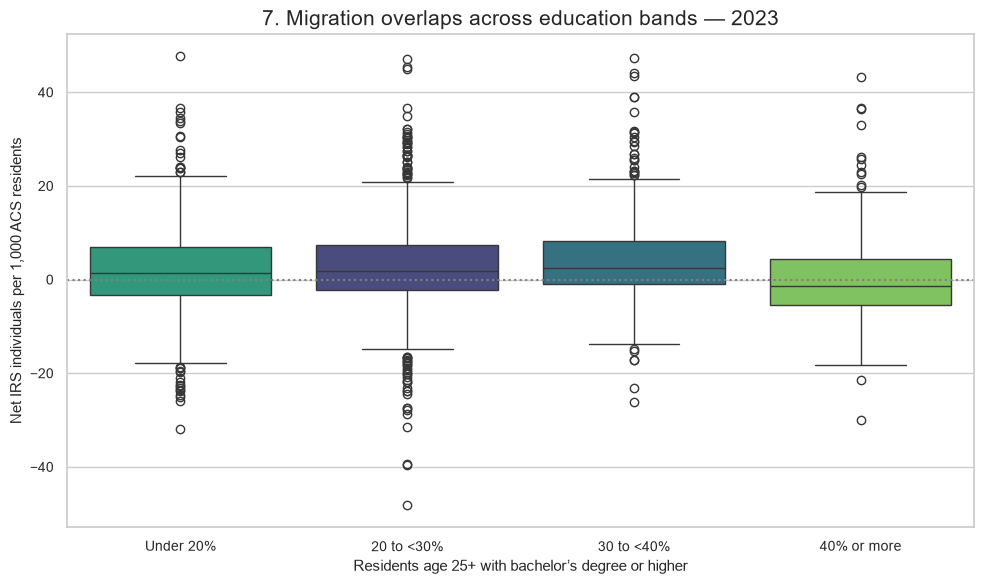

Fixed education bands compare the median, middle half, and flagged tail values of county net migration rates. Visible overlap and retained outliers show why an education category alone cannot determine a county’s migration outcome.

In [9]:
order=['Under 20%','20 to <30%','30 to <40%','40% or more']
fig,ax=plt.subplots(figsize=(10,6))
sns.boxplot(data=cross,x='education_band',y='net_individuals_per_1000',order=order,hue='education_band',palette='viridis',legend=False,showfliers=True,ax=ax)
ax.axhline(0,color='gray',ls=':')
ax.set(title=f'7. Migration overlaps across education bands — {latest}',xlabel='Residents age 25+ with bachelor’s degree or higher',ylabel='Net IRS individuals per 1,000 ACS residents')
charts.append(finish_chart(fig,'07_education_bands.png',
    'Fixed education bands compare the median, middle half, and flagged tail values of county net migration rates.',
    'Visible overlap and retained outliers show why an education category alone cannot determine a county’s migration outcome.'))

## Visualization 8: Similar climates have different migration balances

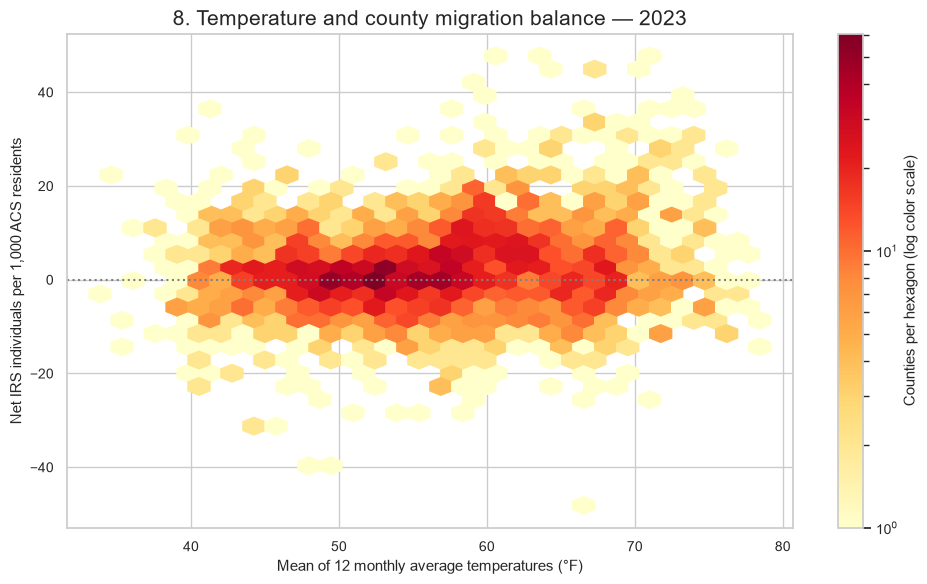

Annual average temperature has a Spearman correlation of 0.15 with net migration, with variation among counties at similar temperatures. Climate is an area average correlated with regional conditions, so this plot does not isolate a temperature effect.

In [10]:
fig,ax=plt.subplots(figsize=(10,6))
hexes=ax.hexbin(cross.temperature_f,cross.net_individuals_per_1000,gridsize=30,mincnt=1,bins='log',cmap='YlOrRd')
fig.colorbar(hexes,ax=ax,label='Counties per hexagon (log color scale)')
ax.axhline(0,color='gray',ls=':')
ax.set(title=f'8. Temperature and county migration balance — {latest}',xlabel='Mean of 12 monthly average temperatures (°F)',ylabel='Net IRS individuals per 1,000 ACS residents')
rho=cross[['temperature_f','net_individuals_per_1000']].corr(method='spearman').iloc[0,1]
charts.append(finish_chart(fig,'08_temperature_and_migration.png',
    f'Annual average temperature has a Spearman correlation of {rho:.2f} with net migration, with variation among counties at similar temperatures.',
    'Climate is an area average correlated with regional conditions, so this plot does not isolate a temperature effect.'))

## Visualization 9: Disaster declaration counts do not separate migration neatly

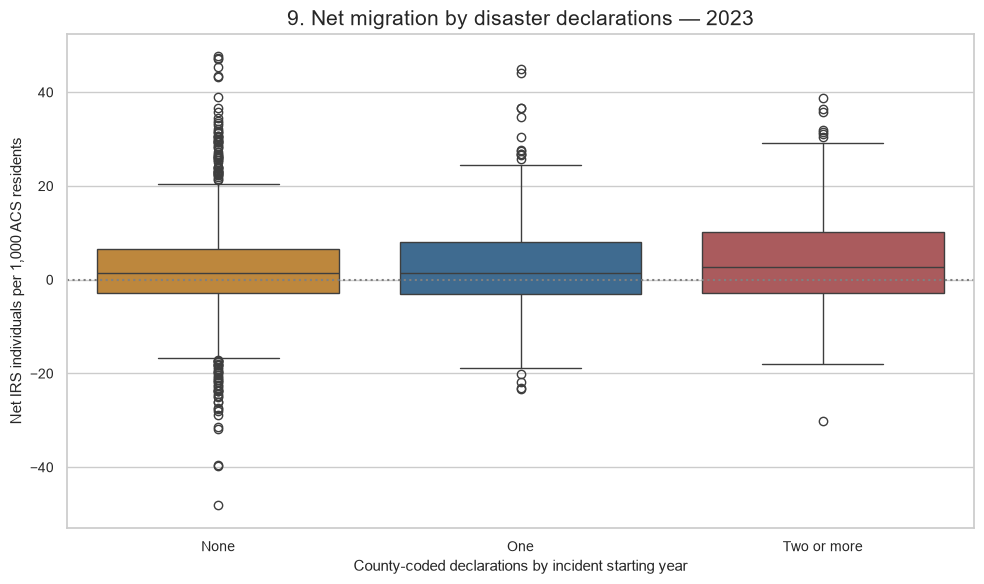

The comparison includes 2,256 counties with no mapped declaration, 610 with one, and 184 with two or more. A zero means no matching declaration rather than no hazard, and these same-year distributions do not identify a disaster’s causal migration impact.

In [11]:
disasters=cross.assign(declaration_group=np.select([cross.declarations.eq(0),cross.declarations.eq(1)],['None','One'],default='Two or more'))
fig,ax=plt.subplots(figsize=(10,6))
sns.boxplot(data=disasters,x='declaration_group',y='net_individuals_per_1000',order=['None','One','Two or more'],hue='declaration_group',palette=[blue,orange,red],legend=False,showfliers=True,ax=ax)
ax.axhline(0,color='gray',ls=':')
ax.set(title=f'9. Net migration by disaster declarations — {latest}',xlabel='County-coded declarations by incident starting year',ylabel='Net IRS individuals per 1,000 ACS residents')
counts=disasters.declaration_group.value_counts()
charts.append(finish_chart(fig,'09_disasters_and_migration.png',
    f'The comparison includes {counts.get("None",0):,} counties with no mapped declaration, {counts.get("One",0):,} with one, and {counts.get("Two or more",0):,} with two or more.',
    'A zero means no matching declaration rather than no hazard, and these same-year distributions do not identify a disaster’s causal migration impact.'))

## Visualization 10: Correlations differ across migration measures

,population,median_age,median_household_income,median_home_value,median_gross_rent,poverty_pct,unemployment_pct,...,bachelors_plus_pct,declarations,precipitation_inches,temperature_f,inflow_individuals_per_1000,outflow_individuals_per_1000,net_individuals_per_1000
population,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
median_age,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
median_household_income,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
median_home_value,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
median_gross_rent,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
poverty_pct,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
unemployment_pct,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
vacancy_pct,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
homeownership_pct,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050
bachelors_plus_pct,3050,3050,3050,3050,3050,3050,3050,...,3050,3050,3050,3050,3050,3050,3050


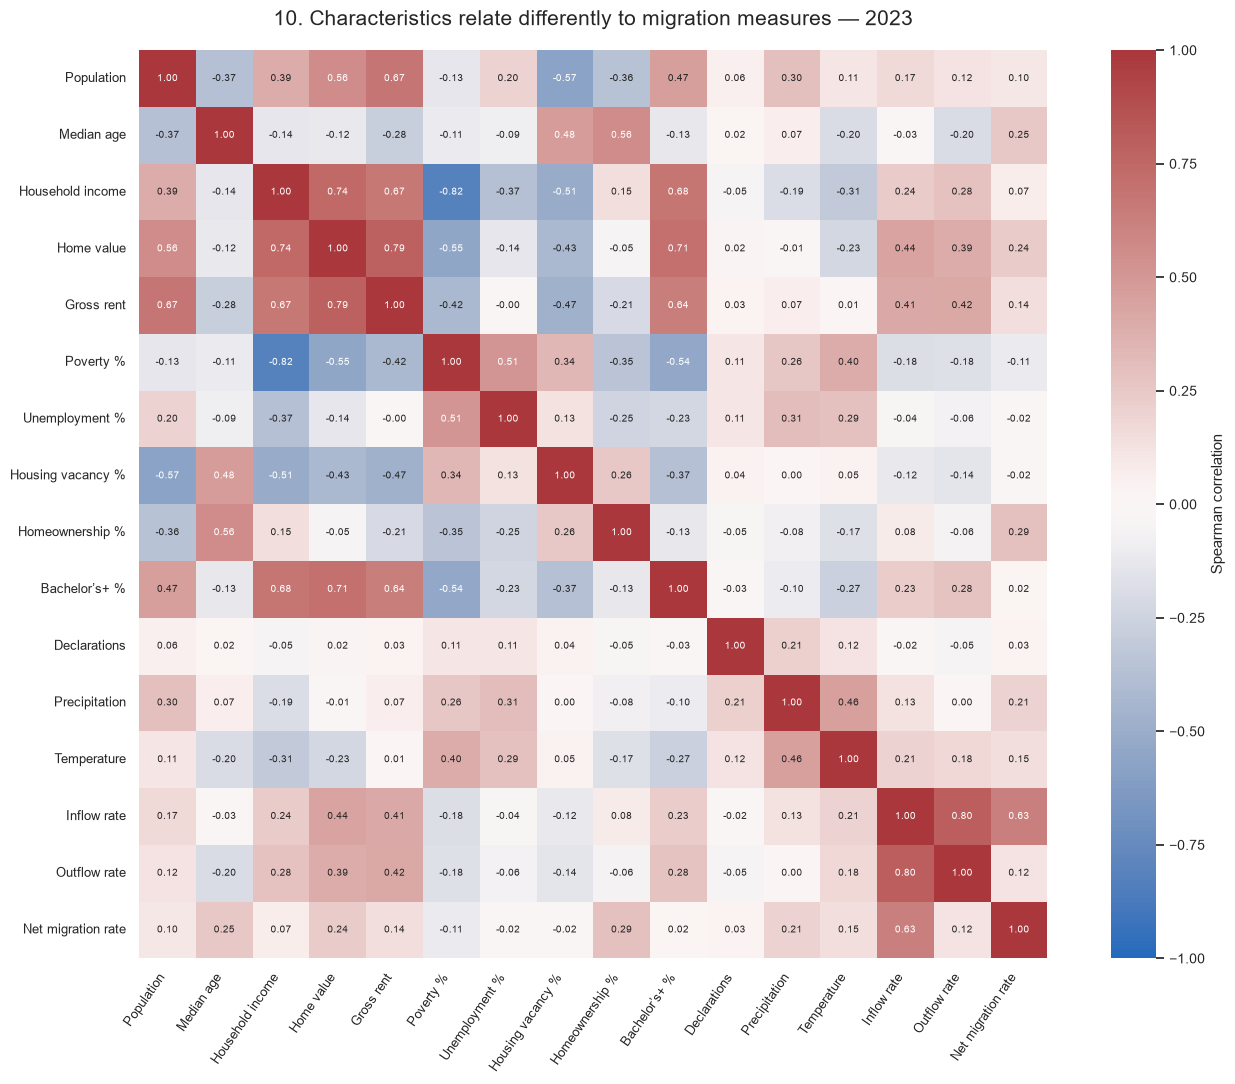

All cells use the same 3,050 complete counties, and homeownership % has the largest absolute rank association with net migration among the selected characteristics. Correlated predictors and different inflow versus outflow relationships motivate multivariable analysis, while this matrix alone provides no causal evidence.

In [12]:
labels={'population':'Population','median_age':'Median age','median_household_income':'Household income','median_home_value':'Home value','median_gross_rent':'Gross rent','poverty_pct':'Poverty %','unemployment_pct':'Unemployment %','vacancy_pct':'Housing vacancy %','homeownership_pct':'Homeownership %','bachelors_plus_pct':'Bachelor’s+ %','declarations':'Declarations','precipitation_inches':'Precipitation','temperature_f':'Temperature','inflow_individuals_per_1000':'Inflow rate','outflow_individuals_per_1000':'Outflow rate','net_individuals_per_1000':'Net migration rate'}
pearson,spearman,pair_counts=correlation_bundle(cross,FEATURES+OUTCOMES,'validated_latest_year')
assert not spearman.isna().any().any()
display(pair_counts)
fig,ax=plt.subplots(figsize=(13,11))
sns.heatmap(spearman.rename(index=labels,columns=labels),vmin=-1,vmax=1,center=0,cmap='vlag',annot=True,fmt='.2f',annot_kws={'size':7},square=True,cbar_kws={'label':'Spearman correlation'},ax=ax)
ax.set_title(f'10. Characteristics relate differently to migration measures — {latest}',pad=18)
ax.tick_params(axis='x',rotation=55,labelsize=9); ax.tick_params(axis='y',rotation=0,labelsize=9)
for label in ax.get_xticklabels(): label.set_ha('right')
ranked=spearman.loc[FEATURES,'net_individuals_per_1000'].sort_values(key=lambda s:s.abs(),ascending=False)
charts.append(finish_chart(fig,'10_correlation_matrix.png',
    f'All cells use the same {len(cross):,} complete counties, and {labels[ranked.index[0]].lower()} has the largest absolute rank association with net migration among the selected characteristics.',
    'Correlated predictors and different inflow versus outflow relationships motivate multivariable analysis, while this matrix alone provides no causal evidence.'))

## Saved chart catalog and interpretation limits

In [13]:
assert len(charts)==10
assert all((ROOT/entry['image']).is_file() for entry in charts)
pd.DataFrame(charts).to_csv(TABLES/'eda_chart_catalog.csv',index=False)
nl=chr(10)
(ROOT/'reports/eda_visualizations.md').write_text('# Ten findings from cleaned analysis data'+nl+nl+
    (nl+nl).join(f'## {i+1}. {Path(item["image"]).stem}'+nl+nl+f'![Chart](../{item["image"]})'+nl+nl+item['caption'] for i,item in enumerate(charts))+nl,encoding='utf-8')
print('Saved ten captioned PNGs and reports/eda_visualizations.md')
display(pd.DataFrame(charts))

Saved ten captioned PNGs and reports/eda_visualizations.md


,image,caption
0,reports/figures/eda/01_population_distribution...,"The median county population is 26,767, while ..."
1,reports/figures/eda/02_home_value_distribution...,The median of county home-value estimates is $...
2,reports/figures/eda/03_net_migration_over_time...,The line tracks median net migration for the s...
3,reports/figures/eda/04_inflow_vs_outflow.png,County inflow and outflow rates have a Spearma...
4,reports/figures/eda/05_county_gains_and_losses...,The chart compares the ten largest gains and t...
5,reports/figures/eda/06_homeownership_and_migra...,The Spearman association between homeownership...
6,reports/figures/eda/07_education_bands.png,"Fixed education bands compare the median, midd..."
7,reports/figures/eda/08_temperature_and_migrati...,Annual average temperature has a Spearman corr...
8,reports/figures/eda/09_disasters_and_migration...,"The comparison includes 2,256 counties with no..."
9,reports/figures/eda/10_correlation_matrix.png,"All cells use the same 3,050 complete counties..."


The cohort includes imputed predictors and does not restore suppressed migration outcomes. Retention tables, source uncertainty, geography flags, and denominator-review exclusions in notebook 01 should accompany these findings; modeling also requires temporal/geographic validation and release-date-aware predictors.